# ISP corpus analysis

## Setup

In [ ]:
import sqlite3

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats


SONG_KEY = ["title", "artist"]
PLATFORMS = ["spotify", "tidal"]
NORMS = ["off", "on"]

## Load corpus

In [18]:
DB_PATH = "/content/corpus.db"

con = sqlite3.connect(DB_PATH)
try:
    df = pd.read_sql_query("SELECT * FROM tracks", con)
finally:
    con.close()

print(f"Loaded {len(df)} tracks")
df.head()

Loaded 1000 tracks


,id,platform,codec,bitrate_kbps,quality_label,normalisation,title,artist,album,release_year,...,true_peak_dbtp,isp_margin_db,has_isp,n_isp_samples,isp_over_fraction,isp_over_pct,integrated_lufs,captured_at,n_isp_events,isp_events_per_min
0,1,spotify,ogg_vorbis,320,very_high,off,Breathe on Me,Britney Spears,In The Zone,2003,...,2.031,2.031,1,28040,0.000353,0.0353,-8.31,2026-09-08T01:16:56.168248+00:00,None,None
1,2,spotify,ogg_vorbis,320,very_high,off,deja vu,Olivia Rodrigo,SOUR,2021,...,0.515,0.515,1,4848,0.000065,0.0065,-9.61,2026-09-08T01:20:31.488963+00:00,None,None
2,3,spotify,ogg_vorbis,320,very_high,off,Wuthering Heights,Kate Bush,The Kick Inside,1978,...,-1.061,0.006,0,0,0.000000,0.0000,-14.44,2026-09-08T01:25:02.052733+00:00,None,None
3,4,spotify,ogg_vorbis,320,very_high,off,Lost in the Fire (feat. The Weeknd),"Gesaffelstein, The Weeknd",Hyperion,2019,...,-1.462,0.084,0,0,0.000000,0.0000,-13.56,2026-09-08T01:28:23.456204+00:00,None,None
4,5,spotify,ogg_vorbis,320,very_high,off,That's My Girl,Fifth Harmony,7/27 (Deluxe),2016,...,0.838,0.838,1,4525,0.000064,0.0064,-7.89,2026-09-08T01:31:48.066249+00:00,None,None


## Help funcs

In [19]:
def rate_table(df, group):
    g = df.groupby(group)
    table = pd.DataFrame({
        "n_tracks": g["has_isp"].count(),
        "n_isp": g["has_isp"].sum(),
        "isp_rate": g["has_isp"].mean(),
        "mean_true_peak": g["true_peak_dbtp"].mean(),
        "mean_isp_margin": g["isp_margin_db"].mean(),
        "mean_lufs": g["integrated_lufs"].mean(),
    })
    return table.round(3).sort_values("isp_rate", ascending=False)


def rate_matrix(df, rows, cols, value="has_isp"):
    return df.pivot_table(index=rows, columns=cols, values=value, aggfunc="mean").round(3)


def paired_wide(df, pair_col, within, value):
    key = SONG_KEY + list(within)
    return df.pivot_table(index=key, columns=pair_col, values=value, aggfunc="first")


def mcnemar(a, b):
    a = np.asarray(a, dtype=int)
    b = np.asarray(b, dtype=int)
    b01 = int(((a == 1) & (b == 0)).sum())
    b10 = int(((a == 0) & (b == 1)).sum())
    n_disc = b01 + b10
    if n_disc == 0:
        p = 1.0
    else:
        p = stats.binomtest(min(b01, b10), n_disc, 0.5).pvalue
    return {"only_a": b01, "only_b": b10, "n_discordant": n_disc, "p": round(float(p), 6)}


def paired_incidence(df, pair_col, value_a, value_b, within):
    wide = paired_wide(df, pair_col, within, "has_isp").dropna(subset=[value_a, value_b])
    res = mcnemar(wide[value_a].values, wide[value_b].values)
    res.update({
        "n_pairs": int(len(wide)),
        "rate_a": round(float(wide[value_a].mean()), 4),
        "rate_b": round(float(wide[value_b].mean()), 4),
    })
    return res


def paired_measure(df, pair_col, value_a, value_b, within, measure):
    wide = paired_wide(df, pair_col, within, measure).dropna(subset=[value_a, value_b])
    diff = (wide[value_b] - wide[value_a]).values
    if len(diff) == 0 or np.allclose(diff, 0):
        p = 1.0
    else:
        _, p = stats.wilcoxon(diff)
    return {
        "measure": measure,
        "n_pairs": int(len(diff)),
        "median_a": round(float(wide[value_a].median()), 3),
        "median_b": round(float(wide[value_b].median()), 3),
        "median_diff_b_minus_a": round(float(np.median(diff)), 3),
        "wilcoxon_p": round(float(p), 6),
    }

## Spotify vs Tidal

In [20]:
print("ISP rate by platform:")
print(rate_table(df, "platform").to_string())
print()

print("ISP rate by platform x normalisation:")
print(rate_matrix(df, "platform", "normalisation").to_string())
print()

print("Paired ISP incidence, tidal vs spotify (McNemar):")
rows = [{"slice": "pooled", **paired_incidence(df, "platform", "spotify", "tidal", within=["normalisation"])}]
for norm in NORMS:
    sub = df[df["normalisation"] == norm]
    rows.append({"slice": f"norm={norm}", **paired_incidence(sub, "platform", "spotify", "tidal", within=[])})
print(pd.DataFrame(rows).to_string(index=False))
print()

print("Paired continuous measures, tidal - spotify (Wilcoxon):")
rows = [paired_measure(df, "platform", "spotify", "tidal", within=["normalisation"], measure=m)
        for m in ["true_peak_dbtp", "isp_margin_db", "integrated_lufs"]]
print(pd.DataFrame(rows).to_string(index=False))

ISP rate by platform:
          n_tracks  n_isp  isp_rate  mean_true_peak  mean_isp_margin  mean_lufs
platform                                                                       
spotify        500    217     0.434          -1.355            0.588    -12.461
tidal          500    188     0.376          -2.031            0.777    -13.113

ISP rate by platform x normalisation:
normalisation    off     on
platform                   
spotify        0.796  0.072
tidal          0.724  0.028

Paired ISP incidence, tidal vs spotify (McNemar):
   slice  only_a  only_b  n_discordant        p  n_pairs  rate_a  rate_b
  pooled      30       1            31 0.000000      500   0.434   0.376
norm=off      19       1            20 0.000040      250   0.796   0.724
 norm=on      11       0            11 0.000977      250   0.072   0.028

Paired continuous measures, tidal - spotify (Wilcoxon):
        measure  n_pairs  median_a  median_b  median_diff_b_minus_a  wilcoxon_p
 true_peak_dbtp      500   

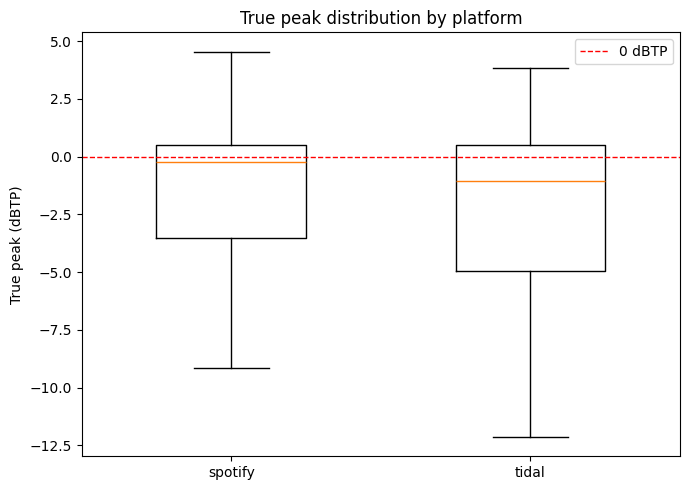

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))
data = [df[df["platform"] == p]["true_peak_dbtp"].dropna().values for p in PLATFORMS]

ax.boxplot(data, widths=0.5)
ax.set_xticks(range(1, 3))
ax.set_xticklabels(PLATFORMS)
ax.axhline(0, color="red", linestyle="--", linewidth=1, label="0 dBTP")
ax.set_ylabel("True peak (dBTP)")
ax.set_title("True peak distribution by platform")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

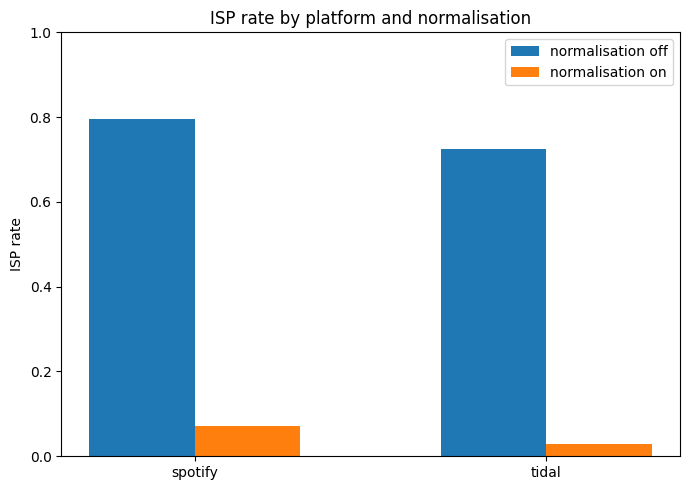

In [22]:
rate_mat = rate_matrix(df, "platform", "normalisation").reindex(index=PLATFORMS, columns=NORMS)
x = np.arange(len(PLATFORMS))

bar_width = 0.3
fig, ax = plt.subplots(figsize=(7, 5))

for i, norm in enumerate(NORMS):
    ax.bar(x + (i - 0.5) * bar_width, rate_mat[norm].values, bar_width, label=f"normalisation {norm}")

ax.set_xticks(x)
ax.set_xticklabels(PLATFORMS)
ax.set_ylabel("ISP rate")
ax.set_ylim(0, 1)
ax.set_title("ISP rate by platform and normalisation")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Normalisation effect within and between platforms

In [23]:
print("ISP rate by normalisation x platform:")
print(rate_matrix(df, "normalisation", "platform").to_string())
print()

print("Paired ISP incidence, on vs off (McNemar):")
rows = []
effects = {}
for platform in PLATFORMS:
    sub = df[df["platform"] == platform]
    res = paired_incidence(sub, "normalisation", "off", "on", within=[])
    effects[platform] = res["rate_b"] - res["rate_a"]
    rows.append({"platform": platform, "d_on_minus_off": round(effects[platform], 4), **res})
print(pd.DataFrame(rows).to_string(index=False))
print()

interaction = effects["tidal"] - effects["spotify"]
print(f"between-platform interaction (tidal - spotify): {round(float(interaction), 4)}")
print()

print("Paired continuous measures, on - off (Wilcoxon):")
rows = []
for platform in PLATFORMS:
    sub = df[df["platform"] == platform]
    for measure in ["true_peak_dbtp", "isp_margin_db", "integrated_lufs"]:
        rows.append({"platform": platform, **paired_measure(sub, "normalisation", "off", "on", within=[], measure=measure)})
print(pd.DataFrame(rows).to_string(index=False))

ISP rate by normalisation x platform:
platform       spotify  tidal
normalisation                
off              0.796  0.724
on               0.072  0.028

Paired ISP incidence, on vs off (McNemar):
platform  d_on_minus_off  only_a  only_b  n_discordant   p  n_pairs  rate_a  rate_b
 spotify          -0.724     181       0           181 0.0      250   0.796   0.072
   tidal          -0.696     174       0           174 0.0      250   0.724   0.028

between-platform interaction (tidal - spotify): 0.028

Paired continuous measures, on - off (Wilcoxon):
platform         measure  n_pairs  median_a  median_b  median_diff_b_minus_a  wilcoxon_p
 spotify  true_peak_dbtp      250     0.489    -3.346                 -4.162    0.000000
 spotify   isp_margin_db      250     0.530     0.203                 -0.214    0.000000
 spotify integrated_lufs      250    -9.530   -14.000                 -4.430    0.000000
   tidal  true_peak_dbtp      250     0.504    -4.859                 -5.679    0.000

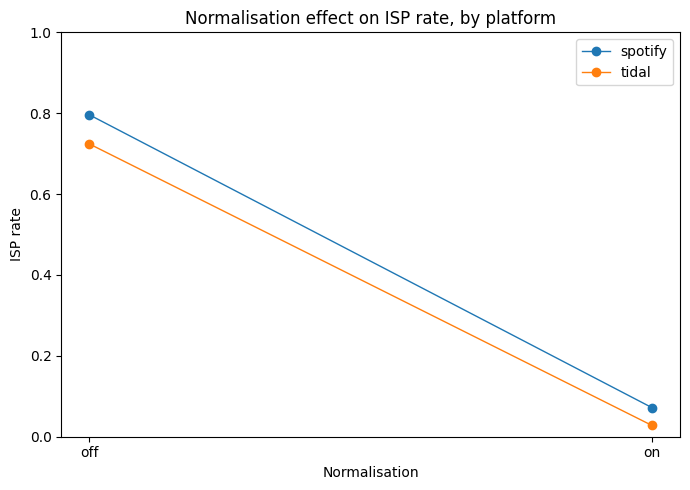

In [24]:
rate_mat = rate_matrix(df, "normalisation", "platform").reindex(index=NORMS, columns=PLATFORMS)
fig, ax = plt.subplots(figsize=(7, 5))

for platform in PLATFORMS:
    ax.plot(NORMS, rate_mat[platform].values, marker="o", linewidth=1.0, label=platform)

ax.set_ylabel("ISP rate")
ax.set_ylim(0, 1)
ax.set_xlabel("Normalisation")
ax.set_title("Normalisation effect on ISP rate, by platform")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

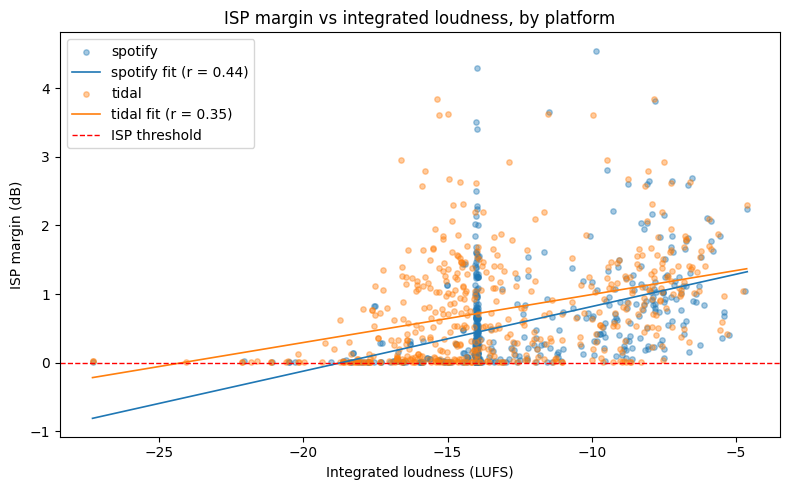

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))

for i, platform in enumerate(PLATFORMS):
    sub = df[df["platform"] == platform].dropna(subset=["integrated_lufs", "isp_margin_db"])

    ax.scatter(sub["integrated_lufs"], sub["isp_margin_db"], label=platform, alpha=0.4, s=15)
    slope, intercept, r, *_ = stats.linregress(sub["integrated_lufs"], sub["isp_margin_db"])
    x_vals = np.linspace(sub["integrated_lufs"].min(), sub["integrated_lufs"].max(), 100)
    ax.plot(x_vals, slope * x_vals + intercept, linewidth=1.2, label=f"{platform} fit (r = {r:.2f})")

ax.axhline(0, color="red", linestyle="--", linewidth=1.0, label="ISP threshold")
ax.set_xlabel("Integrated loudness (LUFS)")
ax.set_ylabel("ISP margin (dB)")
ax.set_title("ISP margin vs integrated loudness, by platform")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Genre

In [26]:
print(rate_matrix(df.dropna(subset=["genre"]), "genre", "platform").to_string())

print("\nGenre association with ISP (chi-squared, per platform, normalisation=off slice):")
rows = []

for platform in PLATFORMS:
    sub = df[(df["platform"] == platform) & (df["normalisation"] == "off")].dropna(subset=["genre"])
    table = pd.crosstab(sub["genre"], sub["has_isp"])

    chi2, p, dof, _ = stats.chi2_contingency(table)
    n = int(table.values.sum())
    k = min(table.shape) - 1
    v = float(np.sqrt(chi2 / (n * k))) if n and k else float("nan")
    rows.append({"platform": platform, "chi2": round(chi2, 4), "p": round(p, 6),
                 "dof": dof, "cramers_v": round(v, 4), "n": n})

print(pd.DataFrame(rows).to_string(index=False))

platform    spotify  tidal
genre                     
electronic     0.47   0.46
hip-hop        0.44   0.40
jazz           0.33   0.24
pop            0.45   0.39
rock           0.48   0.39

Genre association with ISP (chi-squared, per platform, normalisation=off slice):
platform    chi2   p  dof  cramers_v   n
 spotify 43.6989 0.0    4     0.4181 250
   tidal 34.9107 0.0    4     0.3737 250


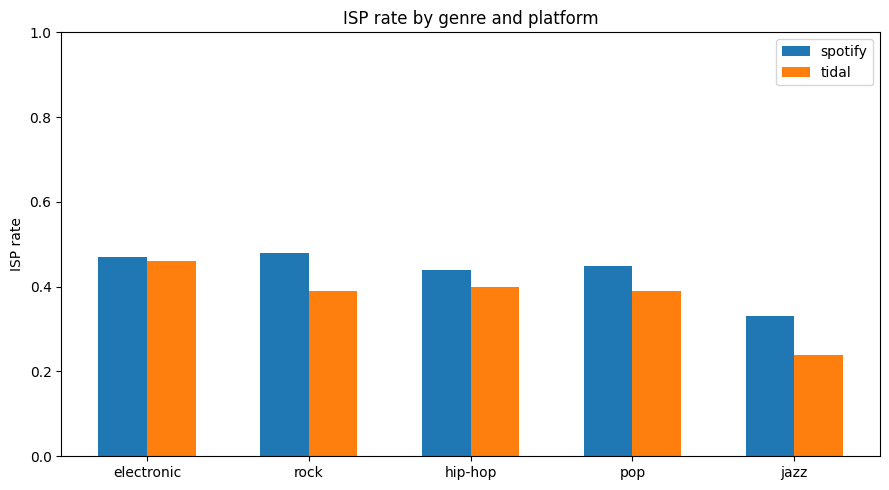

In [27]:
rate_mat = rate_matrix(df.dropna(subset=["genre"]), "genre", "platform")
order = rate_mat.mean(axis=1).sort_values(ascending=False).index
rate_mat = rate_mat.reindex(index=order, columns=PLATFORMS)
x = np.arange(len(order))

bar_width = 0.3
fig, ax = plt.subplots(figsize=(9, 5))

for i, platform in enumerate(PLATFORMS):
    ax.bar(x + (i - 0.5) * bar_width, rate_mat[platform].values, bar_width, label=platform)

ax.set_xticks(x)
ax.set_xticklabels(order)
ax.set_ylabel("ISP rate")
ax.set_ylim(0, 1)
ax.set_title("ISP rate by genre and platform")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()